# 03. ATTR type classifier (prod train)

Обучение типизатора ATTR-span **в этом ноутбуке** (тот же пайплайн, что `_run_04_prod.py`).

**Вход:** `artifacts/attr_type/attr_type_silver_raw.parquet` из [`02_attr_type_silver.ipynb`](./02_attr_type_silver.ipynb).

**Выход:**
- `models/attr_type_clf.joblib`
- `artifacts/attr_type/inference_policy.json` (τ reject)
- отчёт [`attr_type_prod_report.md`](./attr_type_prod_report.md)

## Фичи

| колонка | роль |
|---|---|
| `span_text` | TF-IDF char/word **только** на span |
| `context_text` | `brand` + `category` |
| `query_masked` | word TF-IDF; ATTR → `<ATTR>` |

Пример: `ноутбук asus 16 г` → span=`16 г`, masked=`ноутбук asus <ATTR>`.


## 0. Setup

In [13]:
%matplotlib inline
import sys, json, warnings
from pathlib import Path
from collections import Counter, defaultdict

ROOT = Path.cwd().resolve()
if ROOT.name in {"markov_typer", "notebooks"}:
    ROOT = ROOT.parents[1] if ROOT.name == "markov_typer" else ROOT.parent
sys.path.insert(0, str(ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from src.data_utils import (
    apply_plot_style, ensure_dirs, ARTIFACTS_DIR, FIGURES_DIR, MODELS,
    MVIDEO_RED, DARK_SLATE, save_stats,
)
from src.ner.attr_type_clf import Col, LABEL_UNKNOWN, looks_like_model, predict_attr_type
from src.ner.labeling import ATTR_PATTERNS, _guess_attr_type
from src.ner.markov_typer import MarkovAttrTyper, _norm_token

warnings.filterwarnings("ignore", category=FutureWarning)
ensure_dirs()
apply_plot_style()

OUT = ROOT / "artifacts" / "attr_type"
OUT.mkdir(parents=True, exist_ok=True)
FIG = FIGURES_DIR / "attr_type"
FIG.mkdir(parents=True, exist_ok=True)
SILVER_RAW = OUT / "attr_type_silver_raw.parquet"
REPORT = ROOT / "notebooks" / "markov_typer" / "attr_type_prod_report.md"
print("SILVER_RAW", SILVER_RAW.exists(), SILVER_RAW)


SILVER_RAW True D:\Projects-26-06-2026\mvideo-ner-search\artifacts\attr_type\attr_type_silver_raw.parquet


## 1. Конфиг

In [14]:
SEED = 42
VAL_SIZE = 0.2
MIN_CLASS = 15
UNKNOWN_SHARE_CAP = 0.18
TAU_FLOOR = 0.55   # prod reject: не ниже

assert SILVER_RAW.exists(), "Сначала прогони 02_attr_type_silver.ipynb"


## 2. Все типы атрибутов (учитель)

Имена из `ATTR_PATTERNS` + `color` / `other` / `UNKNOWN` (на train).


In [15]:
pattern_types = sorted({name for _, name in ATTR_PATTERNS})
print(f"ATTR_PATTERNS types ({len(pattern_types)}):")
for t in pattern_types:
    print(f"  - {t}")
print("\n+ color (COLORS), other (no match), UNKNOWN (rare/other на train)")

# sanity teacher fixes
for s in ["16 г", "16 гб", "5 g", "256 g", "1920x1080", "4k", "150 грамм", "2 кг"]:
    print(f"  teacher {s!r:12} -> {_guess_attr_type(s)}")


ATTR_PATTERNS types (28):
  - age_restriction
  - airflow_capacity
  - area
  - connectivity
  - current
  - density
  - dimensions
  - flow_rate
  - frequency
  - impedance
  - ip_rating
  - magnification
  - megapixels
  - memory_storage
  - noise_level
  - pages_yield
  - power
  - quantity
  - resolution_exact
  - resolution_standard
  - rpm
  - size
  - temperature
  - time
  - voltage
  - volume
  - warranty_period
  - weight

+ color (COLORS), other (no match), UNKNOWN (rare/other на train)
  teacher '16 г'       -> memory_storage
  teacher '16 гб'      -> memory_storage
  teacher '5 g'        -> other
  teacher '256 g'      -> memory_storage
  teacher '1920x1080'  -> resolution_exact
  teacher '4k'         -> resolution_standard
  teacher '150 грамм'  -> weight
  teacher '2 кг'       -> weight


## 3. Подготовка обучающей выборки

Типы и лейблы — **только** из `src/ner/labeling.py` (`ATTR_PATTERNS` / `_guess_attr_type` / `COLORS`).  
Никаких unit-aug и синтетических строк: учимся на span’ах из silver_raw.

1. Relabel `y` через `_guess_attr_type`  
2. rare / `other` / model-like → `UNKNOWN` (train hygiene)  
3. stratified train/val


In [16]:
def stratified_split(df, label_col, test_size, seed):
    y = df[label_col].astype(str)
    vc = y.value_counts()
    rare1 = set(vc[vc < 2].index)
    ok, hold = df[~y.isin(rare1)], df[y.isin(rare1)]
    tr, va = train_test_split(ok, test_size=test_size, random_state=seed, stratify=ok[label_col])
    if len(hold):
        tr = pd.concat([tr, hold], ignore_index=True)
    return tr.reset_index(drop=True), va.reset_index(drop=True)


raw = pd.read_parquet(SILVER_RAW)
print(f"silver_raw rows: {len(raw):,}")

# учитель = labeling.py (никаких новых типов)
df = raw.copy()
df["y_old"] = df["y"].astype(str)
df["y"] = df["span_text"].map(_guess_attr_type)
changed = df[df["y"] != df["y_old"]]
print(f"relabeled: {len(changed):,} ({len(changed)/len(df):.1%})")
if len(changed):
    display(changed.groupby(["y_old", "y"]).size().sort_values(ascending=False).head(12).to_frame("n"))

print("teacher type counts:")
display(df["y"].value_counts().to_frame("n"))

# train hygiene only: редкие + other + model-like → UNKNOWN
raw_vc = df["y"].value_counts()
rare = set(raw_vc[raw_vc < MIN_CLASS].index) | {"other"}
print("rare/other -> UNKNOWN:", sorted(rare))

df["y"] = df["y"].where(~df["y"].isin(rare), LABEL_UNKNOWN)
df.loc[df["span_text"].map(lambda s: looks_like_model(str(s))), "y"] = LABEL_UNKNOWN

unk, pos = df[df["y"] == LABEL_UNKNOWN], df[df["y"] != LABEL_UNKNOWN]
max_unk = max(80, int(UNKNOWN_SHARE_CAP * len(pos) / max(1e-6, 1 - UNKNOWN_SHARE_CAP)))
if len(unk) > max_unk:
    unk = unk.sample(n=max_unk, random_state=SEED)
df = pd.concat([pos, unk], ignore_index=True)
vc = df["y"].value_counts()
df = df[df["y"].isin(vc[vc >= MIN_CLASS].index)].copy()

df["context_text"] = (df["brand"].fillna("").astype(str) + " " + df["category"].fillna("").astype(str)).str.strip()
df["query_masked"] = df["query_masked_all_attr"].fillna("").astype(str)

train_df, val_df = stratified_split(df, "y", VAL_SIZE, SEED)
df.to_parquet(OUT / "attr_type_silver_prod.parquet", index=False)
train_df.to_parquet(OUT / "attr_type_train_prod.parquet", index=False)
val_df.to_parquet(OUT / "attr_type_val_prod.parquet", index=False)
train_df.to_parquet(OUT / "attr_type_train.parquet", index=False)
val_df.to_parquet(OUT / "attr_type_val.parquet", index=False)
print(f"train={len(train_df):,} val={len(val_df):,} classes={train_df['y'].nunique()}")


silver_raw rows: 4,364
relabeled: 1,193 (27.3%)


,,n
y_old,y,
type,other,1126
purpose,other,67


teacher type counts:


,n
y,
other,2267
color,594
size,434
memory_storage,278
connectivity,176
volume,152
weight,111
power,96
resolution_exact,48


rare/other -> UNKNOWN: ['area', 'impedance', 'megapixels', 'noise_level', 'other', 'quantity', 'temperature', 'warranty_period']
train=2,010 val=503 classes=15


## 4. Классы и head обучающего датасета

Ниже — **на чём реально учимся**: список классов, support, примеры строк.


=== TRAIN CLASSES ===
['color', 'connectivity', 'current', 'dimensions', 'frequency', 'memory_storage', 'power', 'resolution_exact', 'resolution_standard', 'size', 'time', 'voltage', 'volume', 'weight', 'UNKNOWN']


,train_n,val_n,share_train
y,,,
color,475,119,0.2363
UNKNOWN,362,90,0.1801
size,347,87,0.1726
memory_storage,222,56,0.1104
connectivity,141,35,0.0701
volume,122,30,0.0607
weight,89,22,0.0443
power,77,19,0.0383
resolution_exact,38,10,0.0189



=== train_df.head(15) ===


,span_text,y,brand,category,context_text,query_masked,query_norm,n_attrs_in_query
0,4 кг,weight,,стиральная машинка,стиральная машинка,стиральная машинка <ATTR>,стиральная машинка 4 кг,1
1,встраиваемая,UNKNOWN,,вытяжки кухонные,вытяжки кухонные,вытяжки кухонные <ATTR>,вытяжки кухонные встраиваемая,1
2,160х200,resolution_exact,,матрас,матрас,матрас для <ATTR> <ATTR>,матрас для кровати 160х200,2
3,black,color,Weissgauff,вытяжки,Weissgauff вытяжки,weissgauff dubhe 600 <ATTR> touch вытяжка,weissgauff dubhe 600 black touch вытяжка,1
4,240 гц,frequency,,монитор,монитор,монитор <ATTR> изогнутый,монитор 240 гц изогнутый,1
5,50 см,size,,газовые плиты,газовые плиты,газовая плита духовкой <ATTR>,газовая плита духовкой 50 см,1
6,16 гб,memory_storage,ADATA,оперативная память,ADATA оперативная память,оперативная память adata ad5u560016 g s <ATTR>,оперативная память adata ad5u560016 g s 16 гб,1
7,45 см,size,,вытяжки кухонные,вытяжки кухонные,вытяжки кухонные <ATTR> <ATTR>,вытяжки кухонные встраиваемая 45 см,2
8,кухню,UNKNOWN,,телевизоры,телевизоры,телевизор smart маленький на <ATTR>,телевизор smart маленький на кухню,1
9,512 гб,memory_storage,Xiaomi,смартфоны,Xiaomi смартфоны,xiaomi смартфон redmi note 15 pro глобальная в...,xiaomi смартфон redmi note 15 pro глобальная в...,1



=== examples per class (up to 3) ===
  color                  ['black', 'черный', 'золотой']
  connectivity           ['bluetooth', 'wi fi', 'lte']
  current                ['11 a', '5 a', '1xusb3.0 a']
  dimensions             ['160х48х54', '50х50', '180x200x22']
  frequency              ['240 гц', '4800 мгц', '120 гц']
  memory_storage         ['16 гб', '512 гб', '2 тб']
  power                  ['601308 w', '900 вт', '1000 вт']
  resolution_exact       ['160х200', '1920x1080', '200x100']
  resolution_standard    ['uhd', 'hd', 'full hd']
  size                   ['50 см', '45 см', '60 см']
  time                   ['i7-11600 h', 'i5-13420 h', '210 h']
  voltage                ['20 v', '220 в', '9 в']
  volume                 ['4 l', '50 л', '8 литров']
  weight                 ['4 кг', '7 кг', '10 кг']
  UNKNOWN                ['встраиваемая', 'кухню', 'электрическая']


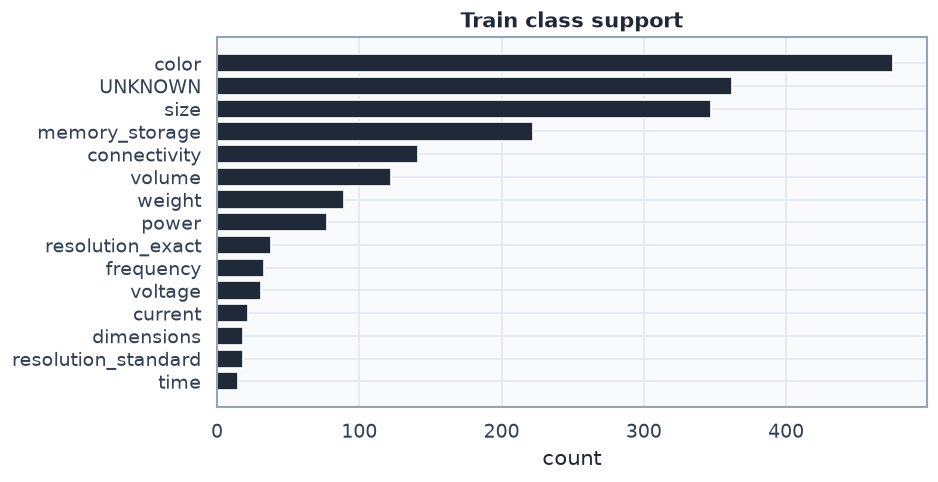

In [17]:
classes = sorted(train_df["y"].unique(), key=lambda x: (x == LABEL_UNKNOWN, x))
print("=== TRAIN CLASSES ===")
print(classes)

cls_tbl = (
    train_df["y"].value_counts()
    .rename("train_n")
    .to_frame()
    .join(val_df["y"].value_counts().rename("val_n"))
    .fillna(0).astype(int)
)
cls_tbl["share_train"] = (cls_tbl["train_n"] / cls_tbl["train_n"].sum()).round(4)
display(cls_tbl)

print("\n=== train_df.head(15) ===")
show_cols = [c for c in [
    "span_text", "y", "brand", "category", "context_text", "query_masked",
    "query_norm", "n_attrs_in_query",
] if c in train_df.columns]
display(train_df[show_cols].head(15))

print("\n=== examples per class (up to 3) ===")
for c in classes:
    ex = train_df.loc[train_df["y"] == c, "span_text"].drop_duplicates().head(3).tolist()
    print(f"  {c:22} {ex}")

fig, ax = plt.subplots(figsize=(8, 4.2))
vc_plot = train_df["y"].value_counts()
ax.barh(vc_plot.index.astype(str)[::-1], vc_plot.values[::-1], color=DARK_SLATE)
ax.set_title("Train class support")
ax.set_xlabel("count")
fig.tight_layout()
fig.savefig(FIG / "prod_02_class_support.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. Четыре модели + Markov

| id | фичи |
|---|---|
| `logreg_span_char` | char на span |
| `logreg_span_wordchar` | word+char на span |
| `logreg_span_ctx` | span char + context char |
| `sgd_span_ctx_masked` | span char + **word** на `query_masked` |


In [18]:
def make_pipelines(seed=SEED):
    char = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=2, max_features=40_000)
    word = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=1, max_features=15_000)
    lr = dict(max_iter=300, solver="lbfgs", random_state=seed)
    return {
        "logreg_span_char": Pipeline([
            ("span", Col("span_text")),
            ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=2, max_features=40_000)),
            ("clf", LogisticRegression(**lr)),
        ]),
        "logreg_span_wordchar": Pipeline([
            ("feats", FeatureUnion([
                ("char", Pipeline([("c", Col("span_text")), ("t", char)])),
                ("word", Pipeline([("c", Col("span_text")), ("t", word)])),
            ])),
            ("clf", LogisticRegression(**lr)),
        ]),
        "logreg_span_ctx": Pipeline([
            ("feats", FeatureUnion([
                ("span", Pipeline([
                    ("c", Col("span_text")),
                    ("t", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=2, max_features=40_000)),
                ])),
                ("ctx", Pipeline([
                    ("c", Col("context_text")),
                    ("t", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=1, max_features=15_000)),
                ])),
            ])),
            ("clf", LogisticRegression(**lr)),
        ]),
        "sgd_span_ctx_masked": Pipeline([
            ("feats", FeatureUnion([
                ("span", Pipeline([
                    ("c", Col("span_text")),
                    ("t", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=2, max_features=50_000)),
                ])),
                ("masked", Pipeline([
                    ("c", Col("query_masked")),
                    ("t", TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=2, max_features=20_000)),
                ])),
            ])),
            ("clf", SGDClassifier(loss="log_loss", alpha=1e-5, max_iter=50, random_state=seed, tol=1e-3)),
        ]),
    }

PIPELINES = make_pipelines()
print(list(PIPELINES))


['logreg_span_char', 'logreg_span_wordchar', 'logreg_span_ctx', 'sgd_span_ctx_masked']


## 6. Обучение + сводная таблица

In [19]:
ytr = train_df["y"].astype(str).values
yva = val_df["y"].astype(str).values
multi_m = (val_df["n_attrs_in_query"] >= 2).values

results, fitted = {}, {}
for name, pipe in PIPELINES.items():
    print(f"=== train {name} ===")
    pipe.fit(train_df, ytr)
    pred = pipe.predict(val_df)
    pack = {
        "accuracy": float(accuracy_score(yva, pred)),
        "f1_macro": float(f1_score(yva, pred, average="macro", zero_division=0)),
        "f1_micro": float(f1_score(yva, pred, average="micro", zero_division=0)),
        "f1_weighted": float(f1_score(yva, pred, average="weighted", zero_division=0)),
        "report": classification_report(yva, pred, labels=classes, output_dict=True, zero_division=0),
        "pred": pred,
    }
    pack["multi_f1_macro"] = (
        float(f1_score(yva[multi_m], pred[multi_m], average="macro", zero_division=0))
        if multi_m.any() else None
    )
    pack["f1_UNKNOWN"] = float(pack["report"].get(LABEL_UNKNOWN, {}).get("f1-score", 0.0))
    results[name] = pack
    fitted[name] = pipe
    joblib.dump(pipe, OUT / f"prod__{name}.joblib")
    print(f"  acc={pack['accuracy']:.3f} macro={pack['f1_macro']:.3f} multi={pack['multi_f1_macro']} unk={pack['f1_UNKNOWN']:.3f}")

# Markov baseline
markov = MarkovAttrTyper()
_big, _unit, _trans = defaultdict(Counter), defaultdict(Counter), defaultdict(Counter)
for _, r in train_df.iterrows():
    toks = [_norm_token(t) for t in str(r["span_text"]).split()]
    y = str(r["y"])
    markov.n_spans += 1
    for a, b in zip(toks, toks[1:]):
        _big[f"{a}|{b}"][y] += 1
        _trans[a][b] += 1
    if toks:
        _unit[toks[-1]][y] += 1
markov.bigram_to_type = {k: dict(v) for k, v in _big.items()}
markov.unit_to_type = {k: dict(v) for k, v in _unit.items()}
markov.transitions = {k: dict(v) for k, v in _trans.items()}
m_pred = np.array([
    LABEL_UNKNOWN if (lab := markov.predict(s.split())[0]) == "unknown" else lab
    for s in val_df["span_text"].astype(str)
])
results["markov_lookup"] = {
    "accuracy": float(accuracy_score(yva, m_pred)),
    "f1_macro": float(f1_score(yva, m_pred, average="macro", zero_division=0)),
    "f1_micro": float(f1_score(yva, m_pred, average="micro", zero_division=0)),
    "f1_weighted": float(f1_score(yva, m_pred, average="weighted", zero_division=0)),
    "multi_f1_macro": float(f1_score(yva[multi_m], m_pred[multi_m], average="macro", zero_division=0)) if multi_m.any() else None,
    "report": classification_report(yva, m_pred, labels=classes, output_dict=True, zero_division=0),
    "pred": m_pred,
}
results["markov_lookup"]["f1_UNKNOWN"] = float(
    results["markov_lookup"]["report"].get(LABEL_UNKNOWN, {}).get("f1-score", 0.0)
)

summary = pd.DataFrame([
    {
        "model": n,
        "accuracy": v["accuracy"],
        "f1_macro": v["f1_macro"],
        "f1_micro": v["f1_micro"],
        "multi_f1_macro": v.get("multi_f1_macro"),
        "f1_UNKNOWN": v.get("f1_UNKNOWN"),
    }
    for n, v in results.items()
]).sort_values("f1_macro", ascending=False).reset_index(drop=True)
summary.to_csv(OUT / "prod_models_summary.csv", index=False)
summary.to_csv(OUT / "models_summary.csv", index=False)
display(summary)


=== train logreg_span_char ===
  acc=0.974 macro=0.922 multi=1.0 unk=0.941
=== train logreg_span_wordchar ===
  acc=0.978 macro=0.921 multi=0.9883760683760683 unk=0.946
=== train logreg_span_ctx ===
  acc=0.966 macro=0.907 multi=0.9883760683760683 unk=0.925
=== train sgd_span_ctx_masked ===
  acc=0.984 macro=0.956 multi=0.9845368306906769 unk=0.978


,model,accuracy,f1_macro,f1_micro,multi_f1_macro,f1_UNKNOWN
0,sgd_span_ctx_masked,0.984095,0.955609,0.984095,0.984537,0.977778
1,markov_lookup,0.966203,0.929424,0.966203,0.974852,0.916667
2,logreg_span_char,0.974155,0.921670,0.974155,1.000000,0.940541
3,logreg_span_wordchar,0.978131,0.920546,0.978131,0.988376,0.946237
4,logreg_span_ctx,0.966203,0.907375,0.966203,0.988376,0.924731


## 7. Best model: report, threshold, save

BEST = sgd_span_ctx_masked
                     precision    recall  f1-score   support

              color      1.000     0.992     0.996       119
       connectivity      1.000     1.000     1.000        35
            current      1.000     1.000     1.000         6
         dimensions      1.000     0.400     0.571         5
          frequency      1.000     1.000     1.000         8
     memory_storage      0.966     1.000     0.982        56
              power      1.000     1.000     1.000        19
   resolution_exact      0.750     0.900     0.818        10
resolution_standard      1.000     1.000     1.000         5
               size      0.989     0.989     0.989        87
               time      1.000     1.000     1.000         3
            voltage      1.000     1.000     1.000         8
             volume      1.000     1.000     1.000        30
             weight      1.000     1.000     1.000        22
            UNKNOWN      0.978     0.978     0.978       

,class,precision,recall,f1,support
1,connectivity,1.000000,1.000000,1.000000,35
2,current,1.000000,1.000000,1.000000,6
4,frequency,1.000000,1.000000,1.000000,8
6,power,1.000000,1.000000,1.000000,19
12,volume,1.000000,1.000000,1.000000,30
10,time,1.000000,1.000000,1.000000,3
8,resolution_standard,1.000000,1.000000,1.000000,5
13,weight,1.000000,1.000000,1.000000,22
11,voltage,1.000000,1.000000,1.000000,8
0,color,1.000000,0.991597,0.995781,119


tau=0.55  acc=0.984  macro=0.960  coverage=99.4%
saved D:\Projects-26-06-2026\mvideo-ner-search\models\attr_type_clf.joblib
policy tau= 0.55


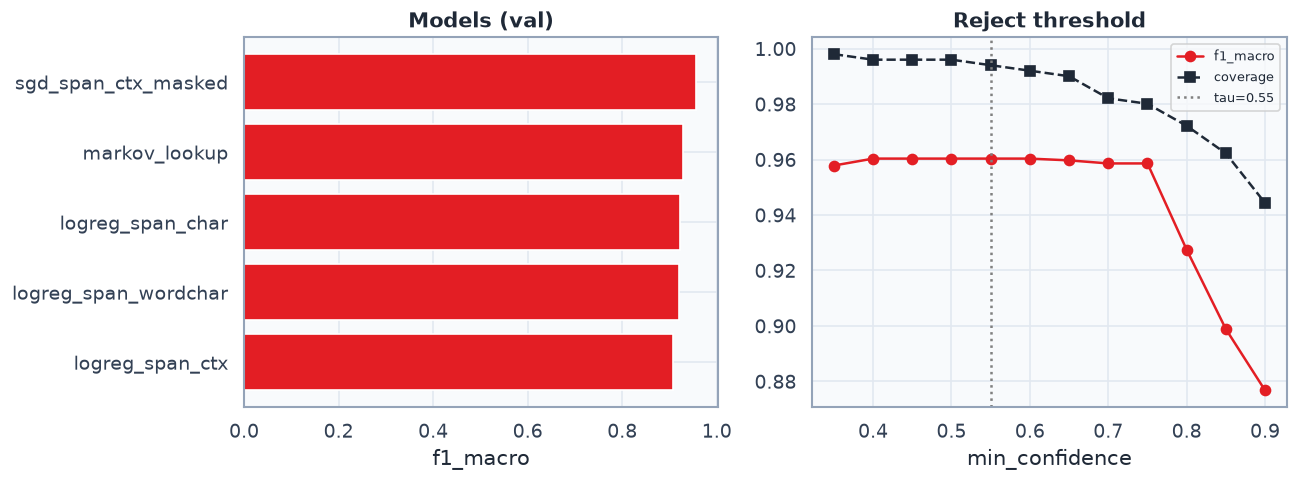

In [20]:
best_name = summary.loc[summary["model"] != "markov_lookup"].iloc[0]["model"]
pipe_best = fitted[best_name]
pred_best = results[best_name]["pred"]
print("BEST =", best_name)
print(classification_report(yva, pred_best, labels=classes, digits=3, zero_division=0))

rep = results[best_name]["report"]
per_class = pd.DataFrame([
    {"class": c, "precision": rep[c]["precision"], "recall": rep[c]["recall"],
     "f1": rep[c]["f1-score"], "support": int(rep[c]["support"])}
    for c in classes if c in rep
]).sort_values("f1", ascending=False)
per_class.to_csv(OUT / "prod_per_class_f1.csv", index=False)
per_class.to_csv(OUT / "per_class_f1__BEST.csv", index=False)
display(per_class)

# calibrate tau >= TAU_FLOOR
proba = pipe_best.predict_proba(val_df)
raw_pred = pipe_best.classes_[proba.argmax(axis=1)]
conf = proba.max(axis=1)
cal_rows = []
for tau in np.round(np.linspace(0.35, 0.90, 12), 2):
    pred = np.where(conf >= tau, raw_pred, LABEL_UNKNOWN)
    cal_rows.append({
        "tau": float(tau),
        "f1_macro": float(f1_score(yva, pred, average="macro", zero_division=0)),
        "accuracy": float(accuracy_score(yva, pred)),
        "coverage": float((conf >= tau).mean()),
    })
cal = pd.DataFrame(cal_rows)
cal_safe = cal[cal["tau"] >= TAU_FLOOR].sort_values(["f1_macro", "coverage"], ascending=[False, False])
tau = float(cal_safe.iloc[0]["tau"]) if len(cal_safe) else TAU_FLOOR
cal.to_csv(OUT / "prod_threshold_curve.csv", index=False)
pred_rej = np.where(conf >= tau, raw_pred, LABEL_UNKNOWN)
print(f"tau={tau}  acc={accuracy_score(yva, pred_rej):.3f}  "
      f"macro={f1_score(yva, pred_rej, average='macro', zero_division=0):.3f}  "
      f"coverage={(conf>=tau).mean():.1%}")

joblib.dump(pipe_best, MODELS / "attr_type_clf.joblib")
joblib.dump(pipe_best, MODELS / f"attr_type_clf__{best_name}.joblib")

policy = {
    "model": best_name,
    "model_path": "models/attr_type_clf.joblib",
    "min_confidence": tau,
    "reject_label": LABEL_UNKNOWN,
    "features": {
        "span_text": "TF-IDF char/word n-grams ONLY on the ATTR span",
        "context_text": "brand + category string (separate TF-IDF)",
        "query_masked": "query with all ATTR spans replaced by <ATTR> (word TF-IDF)",
    },
    "n_train": len(train_df),
    "n_val": len(val_df),
    "classes": classes,
    "val_metrics_raw": {
        "accuracy": results[best_name]["accuracy"],
        "f1_macro": results[best_name]["f1_macro"],
        "multi_f1_macro": results[best_name]["multi_f1_macro"],
        "f1_UNKNOWN": results[best_name]["f1_UNKNOWN"],
    },
    "val_metrics_with_reject": {
        "tau": tau,
        "accuracy": float(accuracy_score(yva, pred_rej)),
        "f1_macro": float(f1_score(yva, pred_rej, average="macro", zero_division=0)),
        "coverage": float((conf >= tau).mean()),
    },
}
(OUT / "inference_policy.json").write_text(json.dumps(policy, ensure_ascii=False, indent=2), encoding="utf-8")
(OUT / "metrics.json").write_text(json.dumps({"best_model": best_name, **policy}, ensure_ascii=False, indent=2), encoding="utf-8")
print("saved", MODELS / "attr_type_clf.joblib")
print("policy tau=", tau)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].barh(summary["model"][::-1], summary["f1_macro"][::-1], color=MVIDEO_RED)
axes[0].set_xlabel("f1_macro"); axes[0].set_title("Models (val)")
axes[1].plot(cal["tau"], cal["f1_macro"], "o-", color=MVIDEO_RED, label="f1_macro")
axes[1].plot(cal["tau"], cal["coverage"], "s--", color=DARK_SLATE, label="coverage")
axes[1].axvline(tau, color="gray", ls=":", label=f"tau={tau}")
axes[1].set_xlabel("min_confidence"); axes[1].legend(fontsize=8)
axes[1].set_title("Reject threshold")
fig.tight_layout()
fig.savefig(FIG / "prod_01_models_threshold.png", dpi=120, bbox_inches="tight")
plt.show()


## 8. Sanity 10 + ручной тест

In [21]:
sanity = [
    {"span": "16 г", "brand": "asus", "category": "ноутбук", "expect": "memory_storage"},
    {"span": "16 гб", "brand": "asus", "category": "ноутбук", "expect": "memory_storage"},
    {"span": "256 g", "brand": "samsung", "category": "смартфон", "expect": "memory_storage"},
    {"span": "5 g", "brand": "samsung", "category": "смартфон", "expect": "UNKNOWN"},
    {"span": "2 кг", "brand": "bosch", "category": "пылесос", "expect": "weight"},
    {"span": "150 грамм", "brand": "", "category": "весы", "expect": "weight"},
    {"span": "1920x1080", "brand": "xiaomi", "category": "монитор", "expect": "resolution_exact"},
    {"span": "4k", "brand": "lg", "category": "телевизор", "expect": "resolution_standard"},
    {"span": "15.6 дюйм", "brand": "asus", "category": "ноутбук", "expect": "size"},
    {"span": "g pro", "brand": "logitech", "category": "наушники", "expect": "UNKNOWN"},
]
sanity_rows = []
for c in sanity:
    det = predict_attr_type(
        c["span"], brand=c["brand"], category=c["category"],
        query_masked=f"{c['category']} {c['brand']} <ATTR>".strip(),
        model_path=MODELS / "attr_type_clf.joblib",
        min_confidence=tau, return_details=True,
    )
    ok = det["label"] == c["expect"]
    sanity_rows.append({
        "span": c["span"], "expect": c["expect"], "pred": det["label"],
        "conf": round(det["confidence"], 3), "ok": ok, "teacher": _guess_attr_type(c["span"]),
    })
    print(f"{'OK' if ok else 'FAIL'} {c['span']!r:12} expect={c['expect']:20} pred={det['label']:20} conf={det['confidence']:.2f}")
sanity_df = pd.DataFrame(sanity_rows)
sanity_df.to_csv(OUT / "prod_sanity_10.csv", index=False)
display(sanity_df)
print(f"sanity {sanity_df.ok.sum()}/{len(sanity_df)}")


OK '16 г'       expect=memory_storage       pred=memory_storage       conf=0.94
OK '16 гб'      expect=memory_storage       pred=memory_storage       conf=0.98
OK '256 g'      expect=memory_storage       pred=memory_storage       conf=0.97
OK '5 g'        expect=UNKNOWN              pred=UNKNOWN              conf=0.21
OK '2 кг'       expect=weight               pred=weight               conf=0.99
FAIL '150 грамм'  expect=weight               pred=size                 conf=0.60
OK '1920x1080'  expect=resolution_exact     pred=resolution_exact     conf=0.90
FAIL '4k'         expect=resolution_standard  pred=color                conf=0.71
OK '15.6 дюйм'  expect=size                 pred=size                 conf=0.98
OK 'g pro'      expect=UNKNOWN              pred=UNKNOWN              conf=1.00


,span,expect,pred,conf,ok,teacher
0,16 г,memory_storage,memory_storage,0.941,True,memory_storage
1,16 гб,memory_storage,memory_storage,0.983,True,memory_storage
2,256 g,memory_storage,memory_storage,0.969,True,memory_storage
3,5 g,UNKNOWN,UNKNOWN,0.207,True,other
4,2 кг,weight,weight,0.988,True,weight
5,150 грамм,weight,size,0.599,False,weight
6,1920x1080,resolution_exact,resolution_exact,0.900,True,resolution_exact
7,4k,resolution_standard,color,0.710,False,resolution_standard
8,15.6 дюйм,size,size,0.981,True,size
9,g pro,UNKNOWN,UNKNOWN,1.000,True,other


sanity 8/10


In [22]:
# --- правь здесь ---
SPAN = "16 г"
BRAND = "asus"
CATEGORY = "ноутбук"
QUERY_MASKED = "ноутбук asus <ATTR>"
# -------------------
det = predict_attr_type(
    SPAN, brand=BRAND, category=CATEGORY, query_masked=QUERY_MASKED,
    model_path=MODELS / "attr_type_clf.joblib", min_confidence=tau, return_details=True,
)
print("teacher:", _guess_attr_type(SPAN))
print(json.dumps({k: ([(a, float(b)) for a, b in v] if k == "top" else v) for k, v in det.items()},
                 ensure_ascii=False, indent=2))


teacher: memory_storage
{
  "label": "memory_storage",
  "raw_pred": "memory_storage",
  "confidence": 0.9408105216502376,
  "rejected": false,
  "reason": "clf",
  "top": [
    [
      "memory_storage",
      0.9408105216502376
    ],
    [
      "weight",
      0.018393642450270874
    ],
    [
      "size",
      0.007488533048859754
    ],
    [
      "current",
      0.006420230822667219
    ],
    [
      "time",
      0.004941747486746786
    ]
  ],
  "min_confidence": 0.55
}


## 9. Отчёт

In [23]:
lines = [
    "# ATTR type classifier — prod report",
    "",
    f"Ноутбук обучения: [`03_attr_type_classifier.ipynb`](./03_attr_type_classifier.ipynb)  ",
    f"Модель: **`{best_name}`** → `models/attr_type_clf.joblib`  ",
    f"Policy: `artifacts/attr_type/inference_policy.json` (τ=`{tau}`)  ",
    f"Sanity: **{int(sanity_df.ok.sum())}/{len(sanity_df)}**",
    "",
    "## Классы train",
    "",
    "| class | train_n | val_n |",
    "|---|---:|---:|",
]
for c, r in cls_tbl.iterrows():
    lines.append(f"| `{c}` | {int(r['train_n'])} | {int(r['val_n'])} |")
lines += [
    "",
    "## Фичи (пример `ноутбук asus 16 г`)",
    "",
    "| фича | значение |",
    "|---|---|",
    "| `span_text` | `16 г` — char TF-IDF |",
    "| `context_text` | `asus ноутбук` |",
    "| `query_masked` | `ноутбук asus <ATTR>` — **word** TF-IDF |",
    "",
    "## Сводка моделей",
    "",
    "| model | acc | f1_macro | multi_f1_macro | f1_UNKNOWN |",
    "|---|---:|---:|---:|---:|",
]
for _, r in summary.iterrows():
    mm = "—" if pd.isna(r["multi_f1_macro"]) else f"{r['multi_f1_macro']:.3f}"
    star = "**" if r["model"] == best_name else ""
    lines.append(
        f"| `{r['model']}` | {r['accuracy']:.3f} | {star}{r['f1_macro']:.3f}{star} | {mm} | {r['f1_UNKNOWN']:.3f} |"
    )
lines += [
    "",
    f"Reject τ={tau}: см. `inference_policy.json`.",
    "",
    "## Sanity 10",
    "",
    "| span | expect | pred | conf | ok | teacher |",
    "|---|---|---|---:|:---:|---|",
]
for _, r in sanity_df.iterrows():
    lines.append(
        f"| `{r['span']}` | {r['expect']} | {r['pred']} | {r['conf']:.2f} | "
        f"{'OK' if r['ok'] else 'FAIL'} | {r['teacher']} |"
    )
lines += ["", "## Per-class F1", "", "| class | precision | recall | f1 | support |", "|---|---:|---:|---:|---:|"]
for _, r in per_class.iterrows():
    lines.append(
        f"| {r['class']} | {r['precision']:.3f} | {r['recall']:.3f} | {r['f1']:.3f} | {int(r['support'])} |"
    )
REPORT.write_text("\n".join(lines) + "\n", encoding="utf-8")
save_stats({"attr_type_clf": policy}, name="attr_type_prod_metrics.json")
print("report ->", REPORT)


Статистика сохранена: D:\Projects-26-06-2026\mvideo-ner-search\artifacts\attr_type_prod_metrics.json
report -> D:\Projects-26-06-2026\mvideo-ner-search\notebooks\markov_typer\attr_type_prod_report.md
